## Ablation Study

In [1]:
scale_ml = 1016/6039 * 100
scale_st = 2940/25390 * 100
scale_fo = 3420/16644 * 100

In [3]:
import numpy as np

np.array([0.3130, 0.5890, 0.3341, 0.6625]) * scale_fo

array([ 6.43150685, 12.10273973,  6.86506849, 13.6130137 ])

In [2]:
abaltion_results = {
    'ml-1m': {
        'original': {
            'ndcg@20': 4.39,
            'recall@20': 7.03,
            'ndcg@50': 5.10,
            'recall@50': 9.41
        },  
        '-rl': {
            'ndcg@20': 3.95,
            'recall@20': 6.17,
            'ndcg@50': 4.78,
            'recall@50': 8.91
        },  
        '-sft': {
            'ndcg@20': 3.56,
            'recall@20': 5.81,
            'ndcg@50': 4.28,
            'recall@50': 8.25
        },  
        '-snake': {
            'ndcg@20': 4.10,
            'recall@20': 6.86,
            'ndcg@50': 4.96,
            'recall@50': 9.44
        },  
    },
    'steam': {
        'original': {
            'ndcg@20': 5.65,
            'recall@20': 8.80,
            'ndcg@50': 5.78,
            'recall@50': 9.30
        },  
        '-rl': {
            'ndcg@20': 5.44,
            'recall@20': 8.33,
            'ndcg@50': 5.55,
            'recall@50': 8.60
        },  
        '-sft': {
            'ndcg@20': 5.05,
            'recall@20': 8.28,
            'ndcg@50': 5.18,
            'recall@50': 8.73
        },  
        '-snake': {
            'ndcg@20': 5.30,
            'recall@20': 8.27,
            'ndcg@50': 5.55,
            'recall@50': 9.06
        },  
    },
    'food': {
        'original': {
            'ndcg@20': 9.82,
            'recall@20': 13.16,
            'ndcg@50': 10.16,
            'recall@50': 14.35
        },  
        '-rl': {
            'ndcg@20': 9.40,
            'recall@20': 11.90,
            'ndcg@50': 9.70,
            'recall@50': 12.98
        },  
        '-sft': {
            'ndcg@20': 6.43,
            'recall@20': 12.10,
            'ndcg@50': 6.87,
            'recall@50': 13.61
        },  
        '-snake': {
            'ndcg@20': 9.72,
            'recall@20': 12.93,
            'ndcg@50': 10.11,
            'recall@50': 14.30
        },  
    }
}

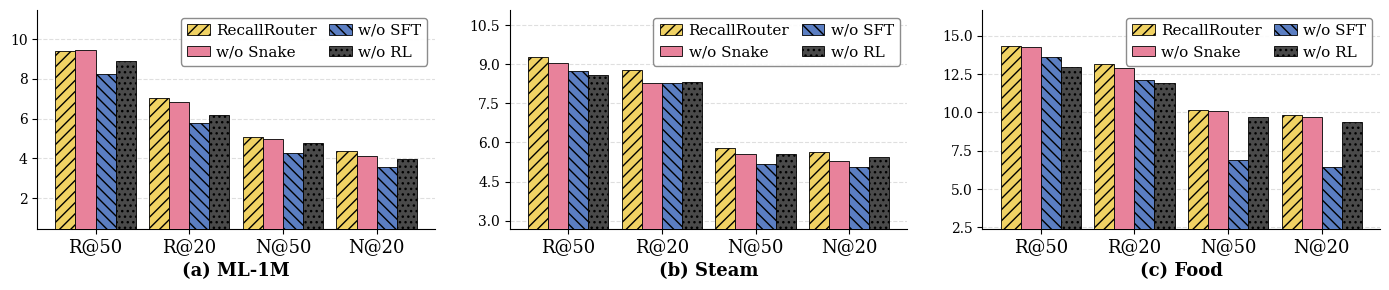

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'stix'

datasets = ['ml-1m', 'steam', 'food']
dataset_labels = ['(a) ML-1M', '(b) Steam', '(c) Food']
metrics = ['recall@50', 'recall@20', 'ndcg@50', 'ndcg@20']
metric_labels = ['R@50', 'R@20', 'N@50', 'N@20']
variants = ['original', '-snake', '-sft', '-rl']
variant_labels = ['RecallRouter', 'w/o Snake', 'w/o SFT', 'w/o RL']

colors = ['#F0D264', '#E8829B', '#5B7EC2', '#4A4A4A']
hatches = ['///', '', '\\\\\\', '...']
edgecolor = 'black'

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

n_groups = len(metrics)
n_bars = len(variants)
bar_width = 0.18
group_gap = 0.12

for ax_idx, (ds, ds_label) in enumerate(zip(datasets, dataset_labels)):
    ax = axes[ax_idx]
    
    x = np.arange(n_groups) * (n_bars * bar_width + group_gap)
    
    for i, (var, var_label) in enumerate(zip(variants, variant_labels)):
        vals = [abaltion_results[ds][var][m] for m in metrics]
        bars = ax.bar(
            x + i * bar_width, vals, bar_width,
            label=var_label,
            color=colors[i],
            hatch=hatches[i],
            edgecolor=edgecolor,
            linewidth=0.6,
            zorder=3
        )
    
    ax.set_xticks(x + bar_width * (n_bars - 1) / 2)
    ax.set_xticklabels(metric_labels, fontsize=13)
    ax.set_xlabel(ds_label, fontsize=13, fontweight='bold')
    
    all_vals = [abaltion_results[ds][v][m] for v in variants for m in metrics]
    ymin = min(all_vals)
    ymax = max(all_vals) + 1
    margin = (ymax - ymin) * 0.15
    ax.set_ylim(bottom=max(0, ymin - margin * 3), top=ymax + margin)

    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(
        fontsize=11, ncol=2,
        loc='upper right',
        frameon=True, framealpha=0.9,
        edgecolor='gray',
        handlelength=1.5, handletextpad=0.4,
        columnspacing=0.8,
    )

plt.tight_layout(w_pad=2.5)
plt.savefig('ablation_study.pdf', dpi=300, bbox_inches='tight')
plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()

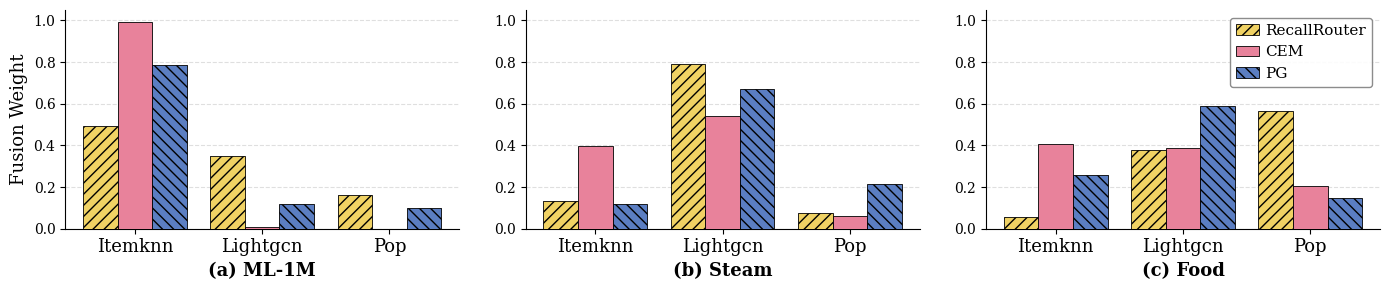

In [4]:
## Weight Comparison - 3 datasets in one figure
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'stix'

datasets = ['ml-1m', 'steam', 'Food']
dataset_labels = ['(a) ML-1M', '(b) Steam', '(c) Food']
combo = 'itemknn_lightgcn_pop'
checkpoint = 'grpo'

colors = ['#F0D264', '#E8829B', '#5B7EC2']
hatches = ['///', '', '\\\\\\']
edgecolor = 'black'

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

bar_width = 0.22
group_gap = 0.15

for ax_idx, (ds, ds_label) in enumerate(zip(datasets, dataset_labels)):
    data_path = f'results/case_study/{ds}_{combo}_{checkpoint}_weight_comparison_data.json'
    with open(data_path) as f:
        data = json.load(f)
    
    recaller_names = data['recaller_names']
    methods = data['methods']
    # Rename "Ours (GRPO)" to "RecallRouter"
    if 'Ours (GRPO)' in methods:
        methods = {'RecallRouter' if k == 'Ours (GRPO)' else k: v for k, v in methods.items()}
    n_recallers = len(recaller_names)
    n_methods = len(methods)
    
    ax = axes[ax_idx]
    x = np.arange(n_recallers) * (n_methods * bar_width + group_gap)
    
    for i, (method_name, weights) in enumerate(methods.items()):
        ax.bar(
            x + i * bar_width, weights, bar_width,
            label=method_name,
            color=colors[i % len(colors)],
            hatch=hatches[i % len(hatches)],
            edgecolor=edgecolor,
            linewidth=0.6,
            zorder=3
        )
    
    ax.set_xticks(x + bar_width * (n_methods - 1) / 2)
    ax.set_xticklabels([r.capitalize() for r in recaller_names], fontsize=13)
    ax.set_xlabel(ds_label, fontsize=13, fontweight='bold')
    
    if ax_idx == 0:
        ax.set_ylabel('Fusion Weight', fontsize=13)
    
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].legend(
    fontsize=11, ncol=1,
    loc='upper right',
    frameon=True, framealpha=0.9,
    edgecolor='gray',
    handlelength=1.5, handletextpad=0.4,
)

plt.tight_layout(w_pad=2.5)
plt.savefig('results/case_study/weight_comparison_all_datasets.pdf', dpi=300, bbox_inches='tight')
plt.savefig('results/case_study/weight_comparison_all_datasets.png', dpi=300, bbox_inches='tight')
plt.show()

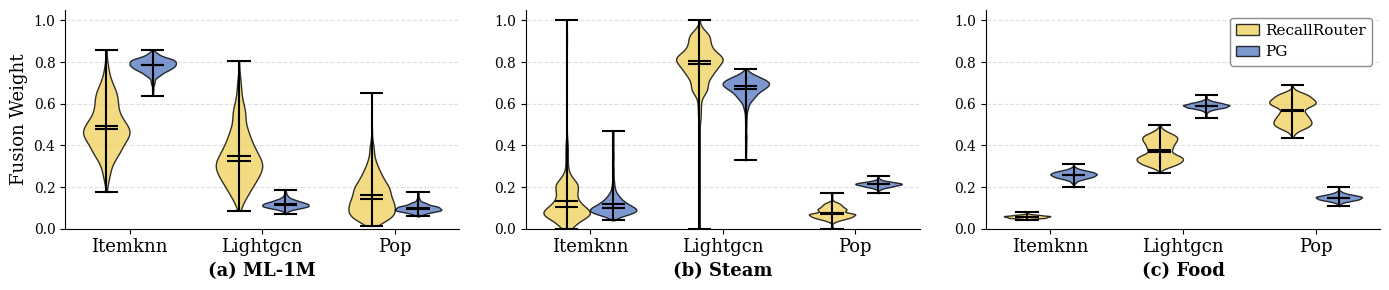

In [5]:
## Weight Distribution - 3 datasets in one figure
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'stix'

datasets = ['ml-1m', 'steam', 'Food']
dataset_labels = ['(a) ML-1M', '(b) Steam', '(c) Food']
combo = 'itemknn_lightgcn_pop'
checkpoint = 'grpo'

colors_ours = '#F0D264'
colors_pg = '#5B7EC2'
edgecolor = 'black'

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax_idx, (ds, ds_label) in enumerate(zip(datasets, dataset_labels)):
    data_path = f'results/case_study/{ds}_{combo}_{checkpoint}_weight_distribution_data.json'
    with open(data_path) as f:
        data = json.load(f)
    
    recaller_names = data['recaller_names']
    ours_weights = np.array(data['ours']['per_user_weights'])
    has_pg = 'pg' in data
    pg_weights = np.array(data['pg']['per_user_weights']) if has_pg else None
    n = len(recaller_names)
    
    ax = axes[ax_idx]
    width = 0.35 if has_pg else 0.6
    
    if has_pg:
        positions_ours = np.arange(n) - width / 2
        positions_pg = np.arange(n) + width / 2
        
        parts_ours = ax.violinplot(
            [ours_weights[:, i] for i in range(n)],
            positions=positions_ours, widths=width,
            showmeans=True, showmedians=True,
        )
        for pc in parts_ours['bodies']:
            pc.set_facecolor(colors_ours)
            pc.set_edgecolor(edgecolor)
            pc.set_alpha(0.8)
        for key in ('cmeans', 'cmedians', 'cmins', 'cmaxes', 'cbars'):
            if key in parts_ours:
                parts_ours[key].set_color(edgecolor)
        
        parts_pg = ax.violinplot(
            [pg_weights[:, i] for i in range(n)],
            positions=positions_pg, widths=width,
            showmeans=True, showmedians=True,
        )
        for pc in parts_pg['bodies']:
            pc.set_facecolor(colors_pg)
            pc.set_edgecolor(edgecolor)
            pc.set_alpha(0.8)
        for key in ('cmeans', 'cmedians', 'cmins', 'cmaxes', 'cbars'):
            if key in parts_pg:
                parts_pg[key].set_color(edgecolor)
    else:
        parts = ax.violinplot(
            [ours_weights[:, i] for i in range(n)],
            positions=range(n), widths=width,
            showmeans=True, showmedians=True,
        )
        for pc in parts['bodies']:
            pc.set_facecolor(colors_ours)
            pc.set_edgecolor(edgecolor)
            pc.set_alpha(0.8)
        for key in ('cmeans', 'cmedians', 'cmins', 'cmaxes', 'cbars'):
            if key in parts:
                parts[key].set_color(edgecolor)
    
    ax.set_xticks(range(n))
    ax.set_xticklabels([r.capitalize() for r in recaller_names], fontsize=13)
    ax.set_xlabel(ds_label, fontsize=13, fontweight='bold')
    
    if ax_idx == 0:
        ax.set_ylabel('Fusion Weight', fontsize=13)
    
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].legend(
    handles=[Patch(facecolor=colors_ours, edgecolor=edgecolor, alpha=0.8, label='RecallRouter'),
             Patch(facecolor=colors_pg, edgecolor=edgecolor, alpha=0.8, label='PG')],
    fontsize=11, ncol=1,
    loc='upper right',
    frameon=True, framealpha=0.9,
    edgecolor='gray',
    handlelength=1.5, handletextpad=0.4,
)

plt.tight_layout(w_pad=2.5)
plt.savefig('results/case_study/weight_distribution_all_datasets.pdf', dpi=300, bbox_inches='tight')
plt.savefig('results/case_study/weight_distribution_all_datasets.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
## Dataset Statistics - LaTeX Table (5-core filtered)
import pandas as pd
import numpy as np

def apply_5core_filter(df, user_col, item_col, k=5):
    """Apply k-core filtering iteratively until convergence."""
    prev_len = -1
    while len(df) != prev_len:
        prev_len = len(df)
        user_counts = df[user_col].value_counts()
        valid_users = user_counts[user_counts >= k].index
        df = df[df[user_col].isin(valid_users)]
        item_counts = df[item_col].value_counts()
        valid_items = item_counts[item_counts >= k].index
        df = df[df[item_col].isin(valid_items)]
    return df

datasets = {
    'ML-1M': {'path': 'dataset/ml-1m/ml-1m.inter', 'user_col': 'user_id:token', 'item_col': 'item_id:token', 'domain': 'Movie'},
    'Steam': {'path': 'dataset/steam/steam.inter', 'user_col': 'user_id:token', 'item_col': 'product_id:token', 'domain': 'Game'},
    'Food': {'path': 'dataset/Food/Food.inter', 'user_col': 'user_id:token', 'item_col': 'item_id:token', 'domain': 'Recipe'},
}

stats = []
for name, config in datasets.items():
    df_raw = pd.read_csv(config['path'], sep='\t')
    df = apply_5core_filter(df_raw.copy(), config['user_col'], config['item_col'], k=5)
    n_users = df[config['user_col']].nunique()
    n_items = df[config['item_col']].nunique()
    n_inter = len(df)
    sparsity = 1 - n_inter / (n_users * n_items)
    avg_len = df.groupby(config['user_col']).size().mean()
    stats.append({'Dataset': name, 'Domain': config['domain'], '#Users': n_users, '#Items': n_items, '#Inter.': n_inter, 'Sparsity': sparsity, 'Avg.Len': avg_len})
    print(f"{name}: {n_users:,} users, {n_items:,} items, {n_inter:,} inter, avg_len={avg_len:.1f}")

def fmt_cnt(x): return f'{int(x):,}'.replace(',', '{,}')  # LaTeX thousands separator
def fmt_sp(x): return f'{x*100:.2f}\\%'
def fmt_len(x): return f'{x:.1f}'

latex = r'''\begin{table}[t]
\centering
\caption{Statistics of the evaluation datasets (after 5-core filtering).}
\label{tab:dataset}
\begin{tabular}{llccccc}
\toprule
Dataset & Domain & \#Users & \#Items & \#Interactions & Sparsity & Avg.Len \\
\midrule
'''
for r in stats:
    latex += f"{r['Dataset']} & {r['Domain']} & {fmt_cnt(r['#Users'])} & {fmt_cnt(r['#Items'])} & {fmt_cnt(r['#Inter.'])} & {fmt_sp(r['Sparsity'])} & {fmt_len(r['Avg.Len'])} \\\\\n"
latex += r'''\bottomrule
\end{tabular}
\end{table}'''
print()
print(latex)

ML-1M: 6,040 users, 3,416 items, 999,611 inter, avg_len=165.5
Steam: 25,389 users, 4,089 items, 328,278 inter, avg_len=12.9
Food: 17,813 users, 41,240 items, 555,618 inter, avg_len=31.2

\begin{table}[t]
\centering
\caption{Statistics of the evaluation datasets (after 5-core filtering).}
\label{tab:dataset}
\begin{tabular}{llccccc}
\toprule
Dataset & Domain & \#Users & \#Items & \#Interactions & Sparsity & Avg.Len \\
\midrule
ML-1M & Movie & 6{,}040 & 3{,}416 & 999{,}611 & 95.16\% & 165.5 \\
Steam & Game & 25{,}389 & 4{,}089 & 328{,}278 & 99.68\% & 12.9 \\
Food & Recipe & 17{,}813 & 41{,}240 & 555{,}618 & 99.92\% & 31.2 \\
\bottomrule
\end{tabular}
\end{table}


In [10]:
## Dataset Feature Fields - Separate LaTeX Table
# User Features, Item Features, Interaction Features

features = {
    'ML-1M': {
        'user': 'age, gender, occupation, zip\\_code',
        'item': 'movie\\_title, release\\_year, genre',
        'inter': 'rating, timestamp',
    },
    'Steam': {
        'user': '—',
        'item': 'app\\_name, developer, genres, price, publisher, sentiment, tags',
        'inter': 'play\\_hours, timestamp',
    },
    'Food': {
        'user': '—',
        'item': 'name, n\\_steps, minutes, nutrition, tags',
        'inter': 'rating, timestamp',
    }
}

latex = r'''\begin{table}[t]
\centering
\caption{Available feature fields for each dataset.}
\label{tab:features}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llll}
\toprule
Dataset & User Features & Item Features & Interaction Features \\
\midrule
'''

for name in ['ML-1M', 'Steam', 'Food']:
    f = features[name]
    latex += f"{name} & {f['user']} & {f['item']} & {f['inter']} \\\\\n"

latex += r'''\bottomrule
\end{tabular}%
}
\end{table}'''

print(latex)

\begin{table}[t]
\centering
\caption{Available feature fields for each dataset.}
\label{tab:features}
\resizebox{\textwidth}{!}{%
\begin{tabular}{llll}
\toprule
Dataset & User Features & Item Features & Interaction Features \\
\midrule
ML-1M & age, gender, occupation, zip\_code & movie\_title, release\_year, genre & rating, timestamp \\
Steam & — & app\_name, developer, genres, price, publisher, sentiment, tags & play\_hours, timestamp \\
Food & — & name, n\_steps, minutes, nutrition, tags & rating, timestamp \\
\bottomrule
\end{tabular}%
}
\end{table}


param_hl_food: 5 windows (created Sun Mar  8 13:25:31 2026)
param_ml_hl_large: 4 windows (created Sun Mar  1 10:53:13 2026)
param_ml_ptk: 5 windows (created Sat Feb 28 06:36:18 2026)
param_ptk_food: 5 windows (created Sat Mar  7 12:06:37 2026)
param_ptk_ml: 4 windows (created Sat Mar  7 04:18:34 2026)
param_ptk_st: 4 windows (created Sat Mar  7 07:20:18 2026)
param_st_hl: 4 windows (created Sun Mar  1 10:51:43 2026)
param_st_hl_large: 4 windows (created Thu Mar  5 20:49:17 2026)
param_st_hl_small: 4 windows (created Thu Mar  5 01:55:11 2026)
param_st_ml_large: 4 windows (created Fri Mar  6 10:19:13 2026)
param_st_ml_small: 5 windows (created Fri Mar  6 21:09:41 2026)
param_st_ptk: 5 windows (created Sat Feb 28 12:02:28 2026)

In [26]:
scale_ml = 1016/6039 
scale_st = 2940/25390 
scale_fo = 3420/16644 
import numpy as np
# four metrics correspond to ndcg@20, ndcg@50, recall@20, recall@50
history_length_results = {
    'ml-1m': {
        5:      np.array([0.2603, 0.4286, 0.3020, 0.5656]) * scale_ml,
        10:     np.array([0.2629, 0.4313, 0.3036, 0.5646]) * scale_ml,
        15:     np.array([0.2631, 0.4219, 0.3050, 0.5585]) * scale_ml,
        20:     np.array([0.0439, 0.0709, 0.0510, 0.0941]),
        25:     np.array([0.2650, 0.4292, 0.3065, 0.5648]) * scale_ml,
        50:     np.array([0.2678, 0.4321, 0.3101, 0.5710]) * scale_ml,
        'inf':  np.array([0.2649, 0.4289, 0.3062, 0.5643]) * scale_ml,
    },
    'steam': {
        5:      np.array([0.4888, 0.7688, 0.4990, 0.8043]) * scale_st,
        10:     np.array([0.4879, 0.7599, 0.4999, 0.8040]) * scale_st,
        15:     np.array([0.4876, 0.7638, 0.4984, 0.8023]) * scale_st,
        20:     np.array([0.0565, 0.0880, 0.0578, 0.0930]),
        25:     np.array([0.4898, 0.7554, 0.5024, 0.8022]) * scale_st,
        50:     np.array([0.4892, 0.7680, 0.4998, 0.8051]) * scale_st,
        'inf':  np.array([0.4921, 0.7588, 0.5038, 0.8024]) * scale_st,
    },
    'food': {
        5:      np.array([0.4482, 0.6416, 0.4653, 0.7003]) * scale_fo,
        10:     np.array([0.4679, 0.7099, 0.4799, 0.8040]) * scale_fo,
        15:     np.array([0.4776, 0.7338, 0.4984, 0.8023]) * scale_fo,
        20:     np.array([0.0982, 0.1316, 0.1016, 0.1435]),
        25:     np.array([0.4898, 0.7554, 0.5024, 0.8022]) * scale_fo,
        50:     np.array([0.4892, 0.7680, 0.4998, 0.8051]) * scale_fo,
        'inf':  np.array([0.4921, 0.7588, 0.5038, 0.8024]) * scale_fo,
    }
}

ptk_results = {
    'ml-1m': {
        0:  np.array([0.2623, 0.4168, 0.3070, 0.5626]) * scale_ml,
        1:  np.array([0.2656, 0.4250, 0.3076, 0.5625]) * scale_ml,
        3:  np.array([0.0439, 0.0709, 0.0510, 0.0941]),
        5:  np.array([0.2679, 0.4295, 0.3106, 0.5688]) * scale_ml,
    },
    'steam': {
        0:  np.array([0.4884, 0.7684, 0.4988, 0.8040]) * scale_st,
        1:  np.array([0.4937, 0.7683, 0.5039, 0.8036]) * scale_st,
        3:  np.array([0.0565, 0.0880, 0.0578, 0.0930]),
        5:  np.array([0.4912, 0.7586, 0.5026, 0.8006]) * scale_st,
    },   
    'food': {
        0:  np.array([0.4683, 0.6294, 0.4849, 0.6886]) * scale_fo,
        1:  np.array([0.4806, 0.6503, 0.4961, 0.7056]) * scale_fo,
        3:  np.array([0.0982, 0.1316, 0.1016, 0.1435]),
        5:  np.array([0.4894, 0.6589, 0.5042, 0.7098]) * scale_fo,
    },   
}


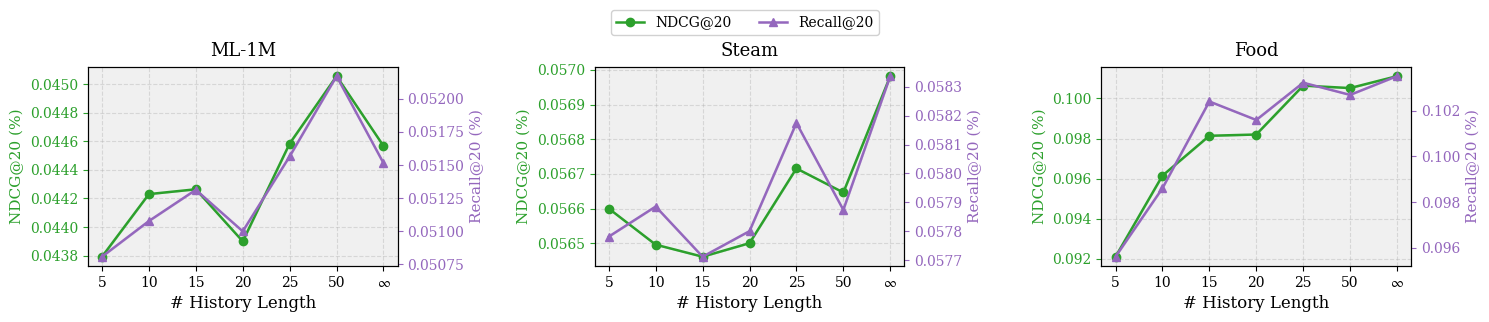

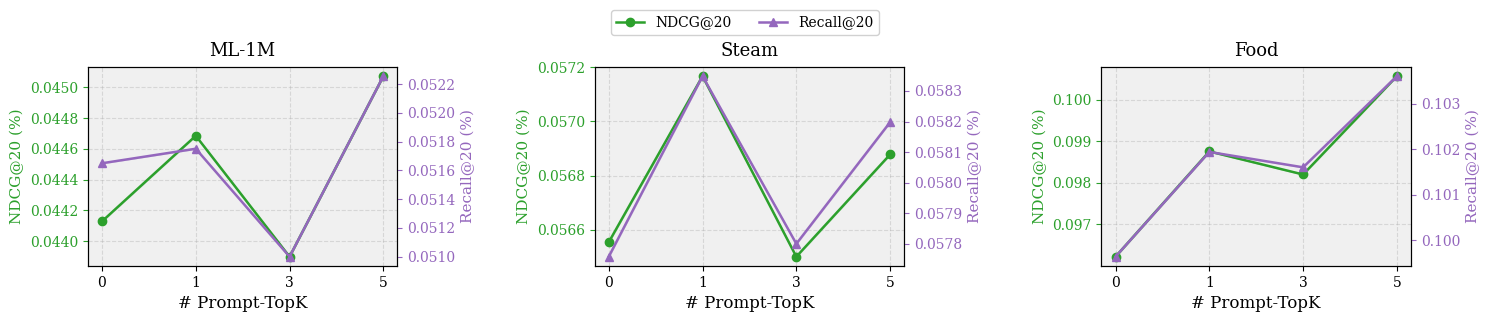

In [27]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'stix'

green_color  = '#2ca02c'
purple_color = '#9467bd'

datasets = ['ml-1m', 'steam', 'food']
dataset_labels = ['ML-1M', 'Steam', 'Food']

def plot_param_study(results, x_label, save_prefix):
    n_ds = len(datasets)
    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 3))
    if n_ds == 1:
        axes = [axes]

    all_handles, all_labels = [], []

    for ax_idx, (ds, ds_label) in enumerate(zip(datasets, dataset_labels)):
        ax_l = axes[ax_idx]
        ax_r = ax_l.twinx()

        ds_data = results[ds]
        x_keys = list(ds_data.keys())
        x_labels_str = [str(k) if k != 'inf' else r'$\infty$' for k in x_keys]
        x_pos = np.arange(len(x_keys))
        vals = np.array([ds_data[k] for k in x_keys])

        # NDCG@20 (index 0) on left axis
        y_ndcg = vals[:, 0]
        std_ndcg = np.zeros_like(y_ndcg)
        ln1, = ax_l.plot(x_pos, y_ndcg, color=green_color, marker='o',
                         linestyle='-', linewidth=1.8, markersize=6,
                         label='NDCG@20', zorder=5)
        ax_l.fill_between(x_pos, y_ndcg - std_ndcg, y_ndcg + std_ndcg,
                          color=green_color, alpha=0.15, zorder=2)

        # Recall@20 (index 2) on right axis
        y_recall = vals[:, 2]
        std_recall = np.zeros_like(y_recall)
        ln2, = ax_r.plot(x_pos, y_recall, color=purple_color, marker='^',
                         linestyle='-', linewidth=1.8, markersize=6,
                         label='Recall@20', zorder=5)
        ax_r.fill_between(x_pos, y_recall - std_recall, y_recall + std_recall,
                          color=purple_color, alpha=0.15, zorder=2)

        if ax_idx == 0:
            all_handles = [ln1, ln2]
            all_labels = ['NDCG@20', 'Recall@20']

        ax_l.set_facecolor('#f0f0f0')
        ax_l.grid(True, linestyle='--', alpha=0.4, zorder=0)
        ax_l.set_xticks(x_pos)
        ax_l.set_xticklabels(x_labels_str, fontsize=11)
        ax_l.set_xlabel(x_label, fontsize=12)
        ax_l.set_title(ds_label, fontsize=13, pad=8)
        ax_l.set_ylabel('NDCG@20 (%)', fontsize=11, color=green_color)
        ax_r.set_ylabel('Recall@20 (%)', fontsize=11, color=purple_color)
        ax_l.tick_params(axis='y', labelsize=10, colors=green_color)
        ax_r.tick_params(axis='y', labelsize=10, colors=purple_color)
        ax_l.tick_params(axis='x', labelsize=10)

    fig.legend(all_handles, all_labels,
               loc='upper center', ncol=2, fontsize=10,
               frameon=True, framealpha=0.9,
               bbox_to_anchor=(0.5, 1.08))
    plt.tight_layout(w_pad=3)
    plt.savefig(f'{save_prefix}.pdf', dpi=300, bbox_inches='tight')
    plt.savefig(f'{save_prefix}.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_param_study(history_length_results, '# History Length', 'param_study_history_length')
plot_param_study(ptk_results, '# Prompt-TopK', 'param_study_ptk')

In [ ]:
import numpy as np

# four metrics correspond to ndcg@20, ndcg@50, recall@20, recall@50

new_hl_grpo_multi = {
    'ml-1m': {
        5:      np.array([0.2614, 0.3043, 0.4192, 0.5602]) * scale_ml,
        10:     np.array([0.2523, 0.2939, 0.4154, 0.5523]) * scale_ml,
        15:     np.array([0.2656, 0.3062, 0.4294, 0.5622]) * scale_ml,
        20:     np.array([0.2634, 0.3064, 0.4311, 0.5716]) * scale_ml,
        25:     np.array([0.2649, 0.3064, 0.4292, 0.5650]) * scale_ml,
        50:     np.array([0.2678, 0.3116, 0.4291, 0.5732]) * scale_ml,
        'inf':  np.array([0.2602, 0.3007, 0.4218, 0.5552]) * scale_ml,
    },
    'steam': {
        5:      np.array([0.4868, 0.4988, 0.7599, 0.8041]) * scale_st,
        10:     np.array([0.4861, 0.4972, 0.7617, 0.8023]) * scale_st,
        15:     np.array([0.4871, 0.4979, 0.7665, 0.8046]) * scale_st,
        20:     np.array([0.4905, 0.5023, 0.7585, 0.8011]) * scale_st,
        25:     np.array([0.4893, 0.5008, 0.7538, 0.7967]) * scale_st,
        50:     np.array([0.4896, 0.5011, 0.7637, 0.8052]) * scale_st,
        'inf':  np.array([0.4926, 0.5032, 0.7662, 0.8036]) * scale_st,
    },
}

new_ptk_grpo_multi = {
    'ml-1m': {
        1:      np.array([0.2615, 0.3078, 0.4185, 0.5696]) * scale_ml,
        3:      np.array([0.2634, 0.3064, 0.4311, 0.5716]) * scale_ml,
        5:      np.array([0.2547, 0.2964, 0.4101, 0.5478]) * scale_ml,
        10:     np.array([0.2561, 0.2967, 0.4242, 0.5572]) * scale_ml,
    },
    'steam': {
        1:      np.array([0.4883, 0.5002, 0.7613, 0.8046]) * scale_st,
        3:      np.array([0.4905, 0.5023, 0.7585, 0.8011]) * scale_st,
        5:      np.array([0.4928, 0.5038, 0.7642, 0.8034]) * scale_st,
        10:     np.array([0.4900, 0.5006, 0.7666, 0.8036]) * scale_st,
    },
}